# 01 - Exploratory Data Analysis: Heart Disease (UCI Cleveland)

**Goal:** understand the data before modelling. Run this notebook top to bottom after `python src/download_data.py`.
Figures are saved to `screenshots/eda/` so you can reuse them in the report.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

DATA = Path("../data/heart_clean.csv")      # notebook lives in notebooks/
FIG_DIR = Path("../screenshots/eda")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save(name):
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

df = pd.read_csv(DATA)
print("Shape:", df.shape)
df.head()

Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 1. Data dictionary

| Column | Meaning | Type |
|---|---|---|
| age | Age in years | numeric |
| sex | 1 = male, 0 = female | binary |
| cp | Chest pain type (1-4) | categorical |
| trestbps | Resting blood pressure (mm Hg) | numeric |
| chol | Serum cholesterol (mg/dl) | numeric |
| fbs | Fasting blood sugar > 120 mg/dl (1 = yes) | binary |
| restecg | Resting ECG result (0-2) | categorical |
| thalach | Maximum heart rate achieved | numeric |
| exang | Exercise-induced angina (1 = yes) | binary |
| oldpeak | ST depression induced by exercise | numeric |
| slope | Slope of peak exercise ST segment (1-3) | categorical |
| ca | Number of major vessels coloured by fluoroscopy (0-3) | categorical/count |
| thal | Thalassemia: 3 = normal, 6 = fixed defect, 7 = reversible defect | categorical |
| target | 0 = no disease, 1 = disease present | **label** |

In [2]:
df.info()
print()
print("Duplicate rows:", df.duplicated().sum())
print()
print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB

Duplicate rows: 0

Missing values per column:
ca      4
thal    2
dtype: int64


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


## 2. Class balance
Is the target roughly balanced? This decides whether accuracy alone is a fair metric.

        count  percent
target                
0         164     54.1
1         139     45.9


C:\Users\yadav\AppData\Local\Temp\ipykernel_19824\623357110.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["No disease (0)", "Disease (1)"])


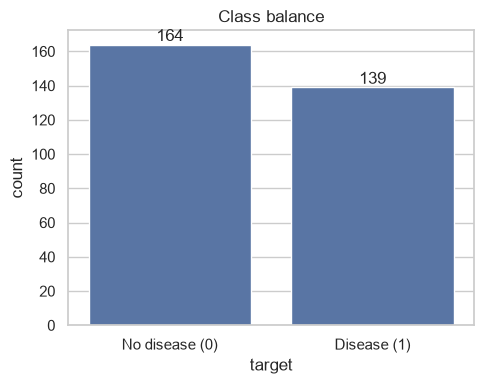

In [4]:
counts = df["target"].value_counts().sort_index()
pct = (counts / len(df) * 100).round(1)
print(pd.DataFrame({"count": counts, "percent": pct}))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x="target", ax=ax)
ax.set_xticklabels(["No disease (0)", "Disease (1)"])
ax.set_title("Class balance")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
save("class_balance")
plt.show()

**Takeaway (write in your own words):** TODO - is the dataset balanced? What does that mean for the metrics you will report?

## 3. Numeric feature distributions

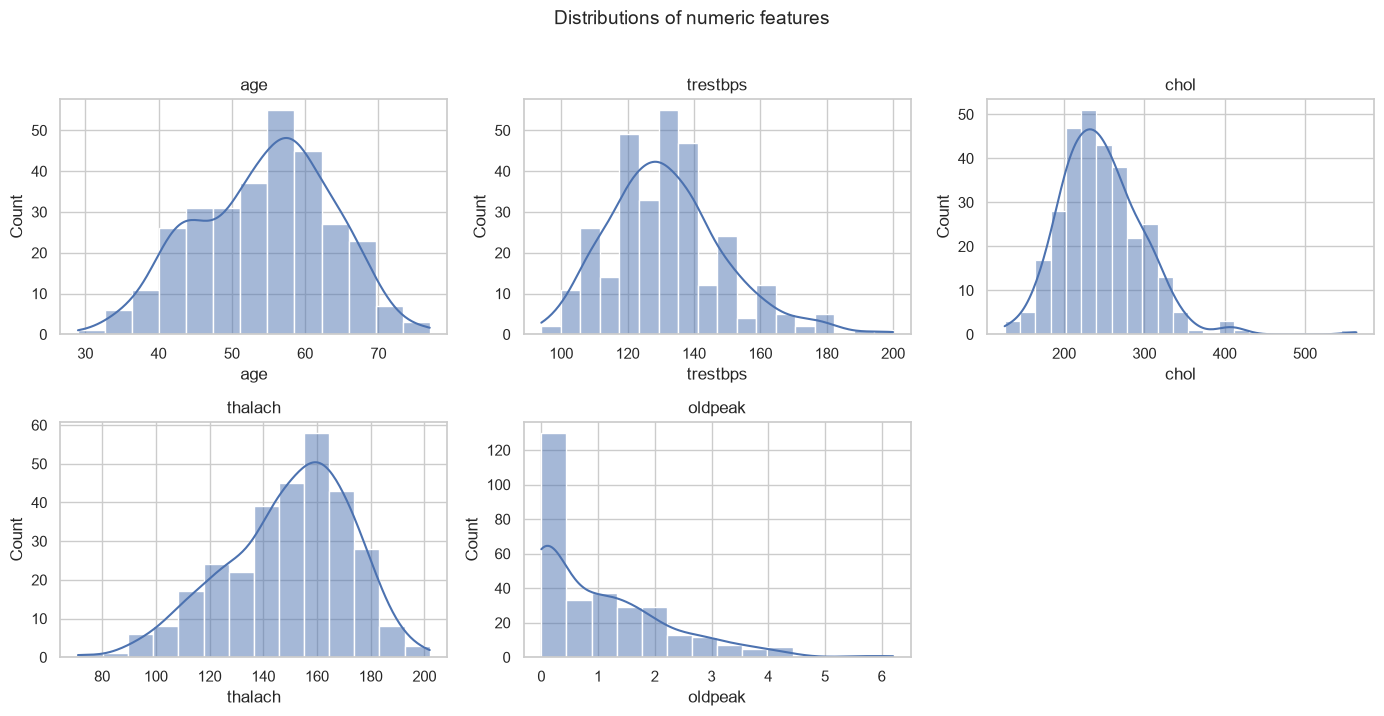

In [5]:
num_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.set_title(col)
axes.ravel()[-1].axis("off")
fig.suptitle("Distributions of numeric features", y=1.02, fontsize=14)
save("numeric_histograms")
plt.show()

**Takeaway (write in your own words):** TODO - any skew, outliers (look at `chol` and `oldpeak`), or odd ranges?

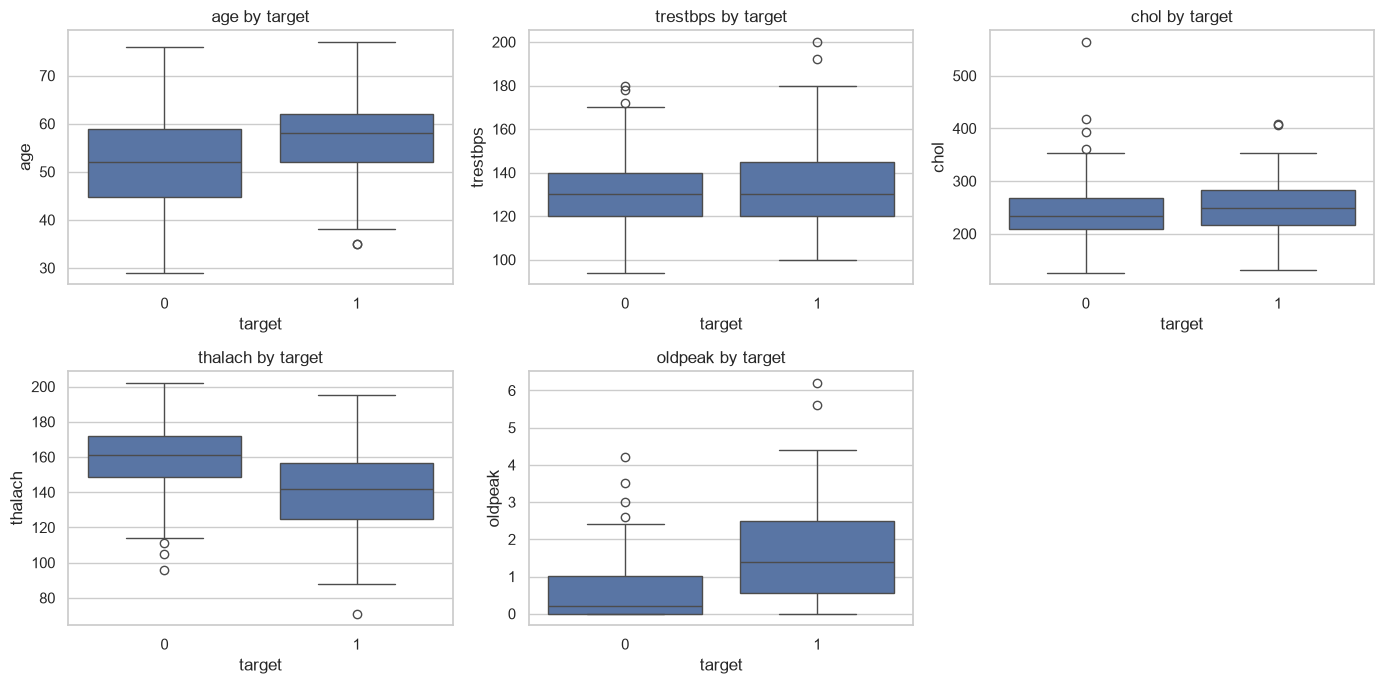

In [6]:
# Same features split by target - which ones separate the classes?
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(data=df, x="target", y=col, ax=ax)
    ax.set_title(f"{col} by target")
axes.ravel()[-1].axis("off")
save("numeric_by_target")
plt.show()

## 4. Correlation heatmap

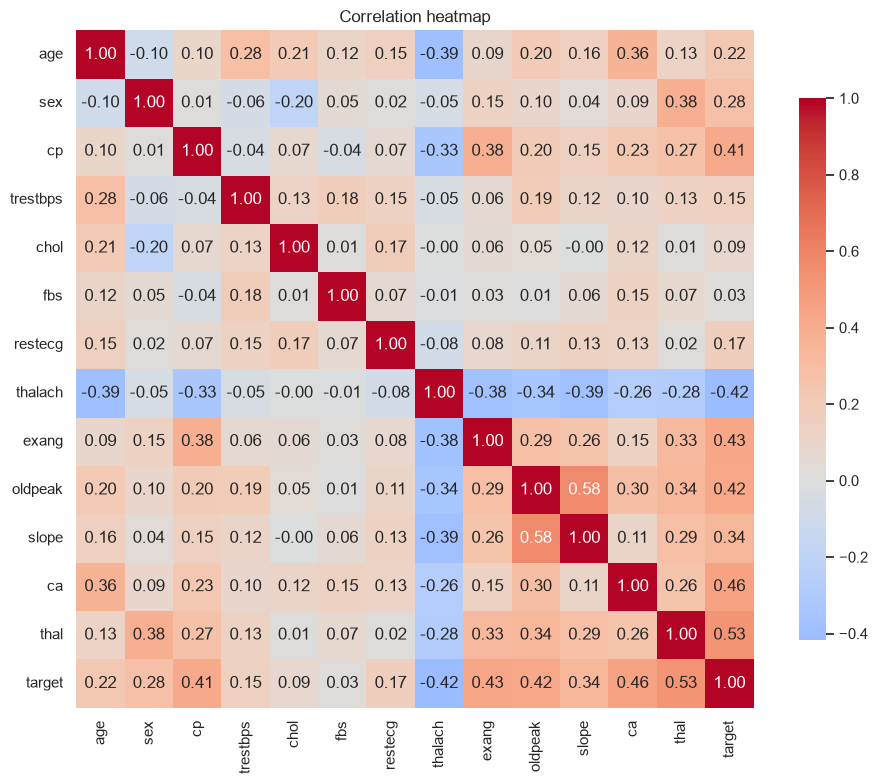

Correlation with target (sorted):
thal        0.53
ca          0.46
exang       0.43
oldpeak     0.42
cp          0.41
slope       0.34
sex         0.28
age         0.22
restecg     0.17
trestbps    0.15
chol        0.09
fbs         0.03
thalach    -0.42
Name: target, dtype: float64


In [7]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.8})
plt.title("Correlation heatmap")
save("correlation_heatmap")
plt.show()

print("Correlation with target (sorted):")
print(corr["target"].drop("target").sort_values(ascending=False).round(2))

**Takeaway (write in your own words):** TODO - which features correlate most with the target? Any pair of features strongly correlated with each other?

## 5. Categorical features vs target

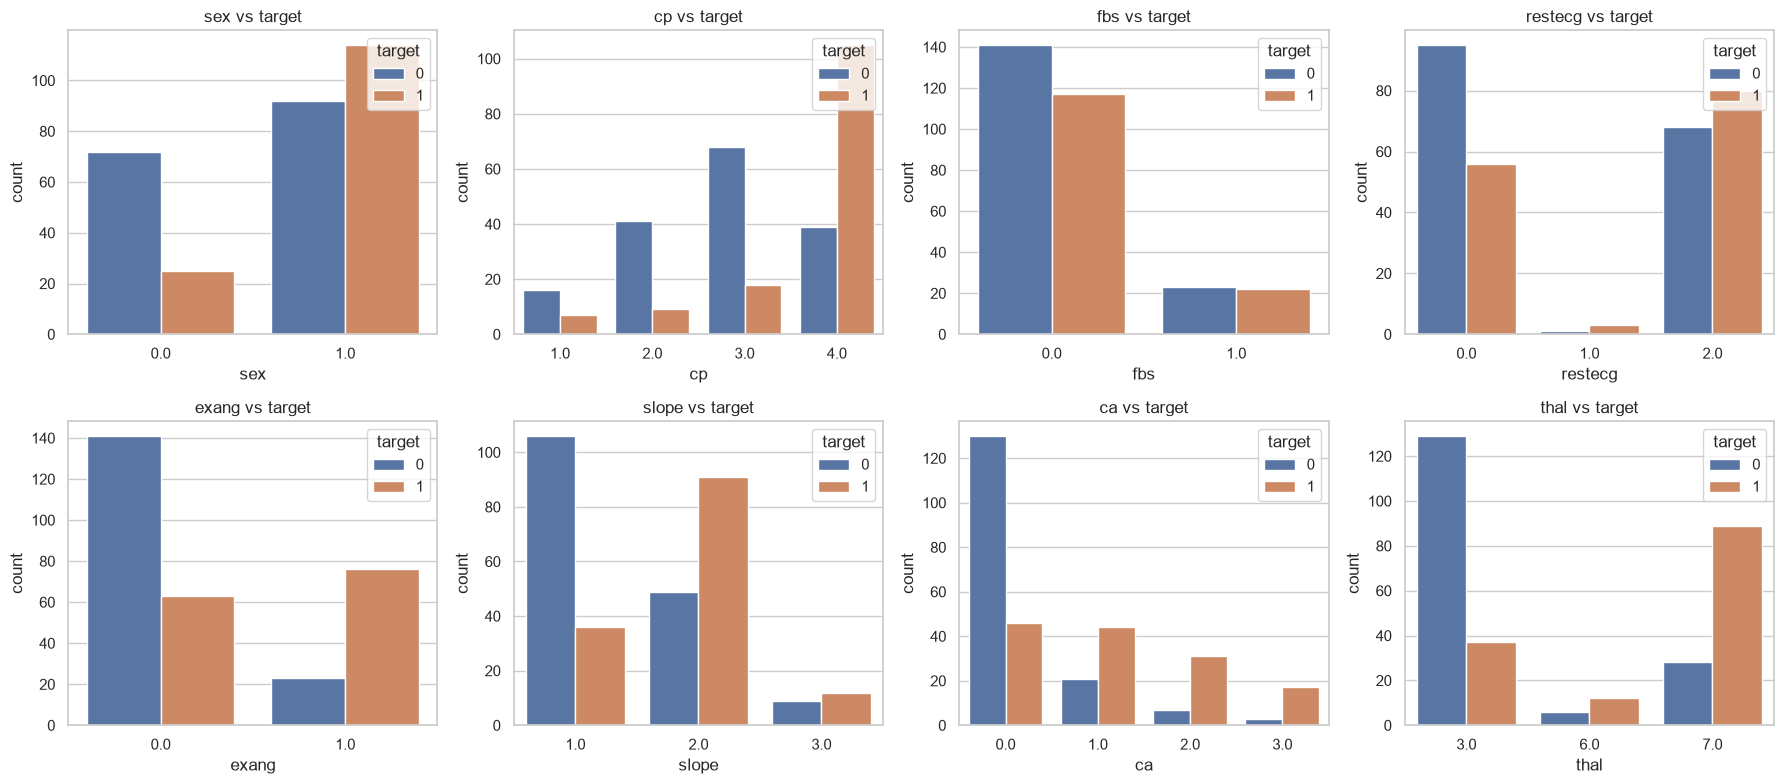

In [8]:
cat_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), cat_cols):
    sns.countplot(data=df, x=col, hue="target", ax=ax)
    ax.set_title(f"{col} vs target")
    ax.legend(title="target", loc="upper right")
save("categorical_vs_target")
plt.show()

**Takeaway (write in your own words):** TODO - which categories show a clear difference between disease and no disease?

## 6. Your own plots (this is what makes your submission different)

Add 1-2 plots of your choice. Ideas, pick what *you* find interesting:
- Disease rate by chest pain type or by age band
- Age vs max heart rate (`thalach`) coloured by target
- A pairplot of 3-4 key features
- Missing-value pattern and how your cleaning choice affects the data

Add a short caption under each.

In [ ]:
# TODO: your own plot(s) here. Call save("your_plot_name") before plt.show()

## 7. EDA summary (copy into the report)

- **Dataset:** TODO (rows, features, source)
- **Cleaning:** TODO (how you handled missing `ca` / `thal`, and why)
- **Class balance:** TODO
- **Key patterns:** TODO (2-3 bullets)
- **Implications for modelling:** TODO (scaling needed? encode which columns? which metric matters most?)